In [1]:
%%capture
!pip install networkx==2.3

In [2]:
import pandas as pd
import networkx as nx
#%matplotlib notebook
import matplotlib.pyplot as plt
import os
import operator
import warnings
warnings.filterwarnings('ignore')
print(os.listdir("../input"))

['openflights-route-database-2014', 'openflights-airports-database-2017']


In [3]:
G_df = pd.read_csv('../input/openflights-route-database-2014/routes.csv')
#Count_df = pd.read_csv('D:/Personal and studies/College/Semester 6/Social and information networks project/countries.txt')
cols_list=["City","Country","IATA"]
airport_df = pd.read_csv('../input/openflights-airports-database-2017/airports.csv',usecols=cols_list)

In [4]:
G_df.head(2)

,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2


In [5]:
#Count_df.head(2)

In [6]:
airport_df.head(2)

,City,Country,IATA
0,Goroka,Papua New Guinea,GKA
1,Madang,Papua New Guinea,MAG


In [7]:
G_draw = nx.from_pandas_edgelist(G_df.head(1000), 'Source airport', 'Destination airport',create_using=nx.DiGraph())

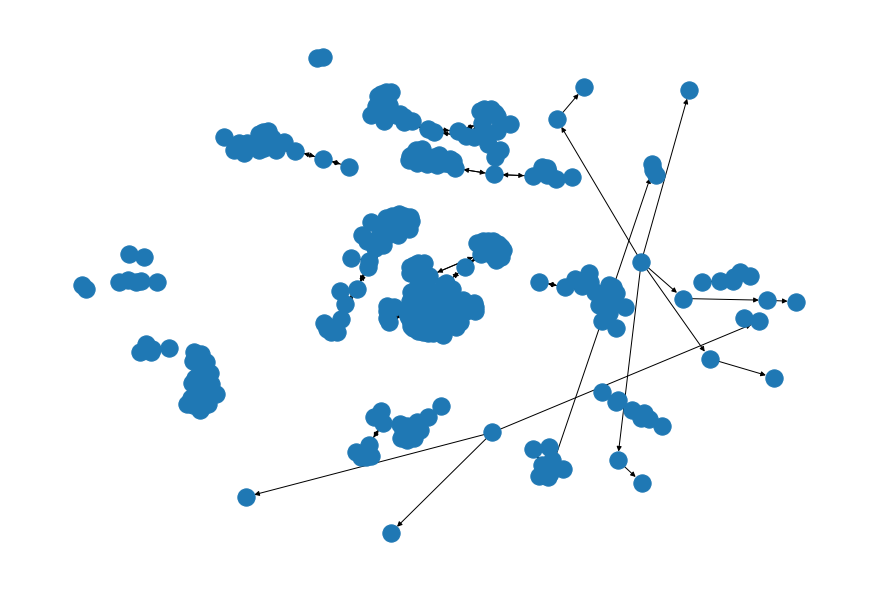

In [8]:
plt.figure(figsize=(12,8))
nx.draw(G_draw,pos=nx.spring_layout(G_draw),with_labels=False)

In [9]:
G = nx.from_pandas_edgelist(G_df, 'Source airport', 'Destination airport',create_using=nx.DiGraph())

In [10]:
print(nx.info(G))

Name: 
Type: DiGraph
Number of nodes: 3425
Number of edges: 37595
Average in degree:  10.9766
Average out degree:  10.9766


In [11]:
#does a route exist between every two airport? #is every airport reachable from every other airport?
nx.is_strongly_connected(G), nx.is_connected(G.to_undirected())

(False, False)

## Weakly and strongly connected components

In [12]:
#How many nodes are in the largest (in terms of nodes) weakly connected component?
wccs = nx.weakly_connected_components(G)
x=len(max(wccs, key=len))
print(x)
print(x/len(G.nodes()))

#so means 99% of graph is weakly connected

3397
0.9918248175182481


In [13]:
#How many nodes are in the largest (in terms of nodes) strongly connected component?
sccs = nx.strongly_connected_components(G)
x=len(max(sccs, key=len))
print(x)
print(x/len(G.nodes()))
#so 97% are strongly connected 

3354
0.9792700729927007


## What is the Average shortest path length?
* Average shortest path length can only be calculated in graphs which are at least weakly connected(otherwise it'll obviously be infinity)
* So we find out average path length for both weakly and strongly connected subgraph

In [14]:
scc_subs = nx.strongly_connected_component_subgraphs(G)
G_sc = max(scc_subs, key=len) #the largest strongly connected subgraph
shortest_sc=nx.average_shortest_path_length(G_sc)
shortest_sc

4.125979351521906

In [15]:
wcc_subs = nx.weakly_connected_component_subgraphs(G)
G_wc = max(wcc_subs, key=len) #the largest weakly connected subgraph
shortest_wc=nx.average_shortest_path_length(G_wc)
shortest_wc

4.093938981010404

In [16]:
len(G_sc.edges())/len(G_sc.nodes()) 

11.178294573643411

In [17]:
len(G_wc.edges())/len(G_wc.nodes())

11.052987930526935

Why is it less for **weakly connected** subgraph? Even though number of edges per node is higher in strongly connected

## Density of a network

In [18]:
nx.density(G),nx.density(G_sc)

(0.003205795074698138, 0.003333818840931527)

## Degrees

In [19]:
degrees = dict(G.degree())
degree_values = sorted(set(degrees.values()))
histogram = [list(degrees.values()).count(i)/float(nx.number_of_nodes(G_sc)) for i in degree_values]

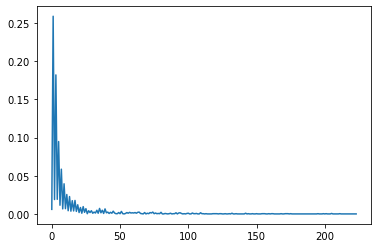

In [20]:
plt.plot(histogram)

## Diameter and radius
* The diameter and radius of weakly connected componenet will obviously be infinity
* The diameter represents the greatest possible no of airports between any two airports
* The radius represents an airport from which every other airport is at a minimum no of airports apart


In [21]:
diameter=nx.diameter(G_sc)
diameter

14

In [22]:
radius=nx.radius(G_sc)
radius

7

## Periphery and Center. Now lets see which airports are these
* Set of nodes which have eccentricity equal to diameter
* Set of nodes eccentricity equal to the radius

In [23]:
per=nx.periphery(G_sc)
per

['YZG', 'XEQ', 'KCG', 'YPO']

In [24]:
airport_df.loc[airport_df['IATA'].isin(per)]

,City,Country,IATA
4228,Peawanuck,Canada,YPO
4241,Salluit,Canada,YZG


In [25]:
cen=nx.center(G_sc)
cen

['CPH', 'KEF']

In [26]:
airport_df.loc[airport_df['IATA'].isin(cen)]

,City,Country,IATA
15,Keflavik,Iceland,KEF
601,Copenhagen,Denmark,CPH


### Which node in G_sc is connected to the most other nodes by a shortest path of length equal to the 
* diameter of G_sc?
* radius of G_sc
How many nodes are connected to this node?

In [27]:
max_count = -1
result_node = None
for node in per:
    count = 0
    sp = nx.shortest_path_length(G_sc, node)
    for key, value in sp.items():
        if value == diameter:
            count += 1        
    if count > max_count:
        result_node = node
        max_count = count

result_node, max_count

('XEQ', 5)

In [28]:
airport_df.loc[airport_df['IATA'] == result_node]

,City,Country,IATA


In [29]:
d = radius
max_count = -1
result_node = None
for node in cen:
    count = 0
    sp = nx.shortest_path_length(G_sc, node)
    for key, value in sp.items():
        if value == radius:
            count += 1        
    if count > max_count:
        result_node = node
        max_count = count

result_node, max_count

('KEF', 8)

In [30]:
airport_df.loc[airport_df['IATA'] == result_node]

,City,Country,IATA
15,Keflavik,Iceland,KEF


### How many and which nodes need to be removed to disconnect result_node?

In [31]:
node = result_node
list(nx.minimum_node_cut(G_sc, cen[0], node)),len(nx.minimum_node_cut(G_sc, cen[0], node))

([], 0)

## Transitivity and Average Clustering Coefficient of

* Strongly connected

In [32]:
nx.transitivity(G_sc), nx.average_clustering(G_sc)

(0.24878205149750107, 0.47733508870492014)

* Weakly connected

In [33]:
nx.transitivity(G_wc), nx.average_clustering(G_wc)

(0.24864166946590527, 0.4708160157290989)

## Indegree and Outdegree
### What are the top and bottom 5 airports with most incoming flights?

In [34]:
in_deg=nx.in_degree_centrality(G_sc)

* Top 5

In [35]:
top5=sorted(in_deg.items(), key=operator.itemgetter(1),reverse=True)[:5]
l=[]
for i,j in top5:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
336,Frankfurt,Germany,FRA
574,Amsterdam,Netherlands,AMS
1346,Paris,France,CDG
3482,Atlanta,United States,ATL
7629,Istanbul,Turkey,IST


* Bottom 5

In [36]:
bot5=sorted(in_deg.items(), key=operator.itemgetter(1))[:5]
l=[]
for i,j in bot5:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
2648,Ayacucho,Peru,AYP
5246,Kirensk,Russia,KCK
5247,Ust-Kut,Russia,UKX
5254,Taganrog,Russia,TGK
6404,Bodaibo,Russia,ODO


### What are the top and bottom 5 airports with most outgoing flights?

In [37]:
out_deg=nx.out_degree_centrality(G_sc)

* Top 5

In [38]:
top5=sorted(out_deg.items(), key=operator.itemgetter(1),reverse=True)[:5]
top5

[('FRA', 0.07127945123769759),
 ('CDG', 0.07068297047420222),
 ('AMS', 0.06919176856546377),
 ('IST', 0.06770056665672533),
 ('ATL', 0.06471816283924844)]

In [39]:
l=[]
for i,j in top5:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
336,Frankfurt,Germany,FRA
574,Amsterdam,Netherlands,AMS
1346,Paris,France,CDG
3482,Atlanta,United States,ATL
7629,Istanbul,Turkey,IST


* Bottom 5

In [40]:
bot5=sorted(out_deg.items(), key=operator.itemgetter(1))[:5]
bot5

[('TGK', 0.00029824038174768865),
 ('KCK', 0.00029824038174768865),
 ('ODO', 0.00029824038174768865),
 ('UKX', 0.00029824038174768865),
 ('AYP', 0.00029824038174768865)]

In [41]:
l=[]
for i,j in bot5:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
2648,Ayacucho,Peru,AYP
5246,Kirensk,Russia,KCK
5247,Ust-Kut,Russia,UKX
5254,Taganrog,Russia,TGK
6404,Bodaibo,Russia,ODO


## Closeness Centrality
### Which airports will allow you to reach all other airports with the lowest average number of airports in between?

In [42]:
closeness = nx.closeness_centrality(G_sc, wf_improved=True)

In [43]:
close=sorted(closeness.items(), key=operator.itemgetter(1),reverse=True)[:5]
l=[]
for i,j in close:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
336,Frankfurt,Germany,FRA
502,London,United Kingdom,LHR
574,Amsterdam,Netherlands,AMS
1346,Paris,France,CDG
2100,Dubai,United Arab Emirates,DXB


### Which airports will make you reach all other airports with the highest average number of airports in between?

In [44]:
close=sorted(closeness.items(), key=operator.itemgetter(1))[:18]
l=[]
for i,j in close:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
9,Thule,Greenland,THU
1009,Isiro,Congo (Kinshasa),IRP
4228,Peawanuck,Canada,YPO
4241,Salluit,Canada,YZG
5409,Perryville,United States,KPV


## Betweenness Centrality
### Which airports often act as bridges between other pairs of airports?

In [45]:
betweeness = nx.betweenness_centrality(G_sc, normalized=True)

In [46]:
close=sorted(betweeness.items(), key=operator.itemgetter(1),reverse=True)[:5]
l=[]
for i,j in close:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
336,Frankfurt,Germany,FRA
1346,Paris,France,CDG
2100,Dubai,United Arab Emirates,DXB
3285,Los Angeles,United States,LAX
3574,Anchorage,United States,ANC


### Which airports least often act as bridges between other pairs of airports?

In [47]:
close=sorted(betweeness.items(), key=operator.itemgetter(1))[:5]
l=[]
for i,j in close:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
5246,Kirensk,Russia,KCK
5247,Ust-Kut,Russia,UKX
5254,Taganrog,Russia,TGK
6404,Bodaibo,Russia,ODO
6442,Lensk,Russia,ULK


## Articulation point, Bridges
* A node is considered an articulation point if the removal of that node (along with all its incident edges) increases the number of connected components of a network
* A bridge in a graph is an edge whose removal causes the number of connected components of the graph to increase.

In [48]:
arti=list(nx.articulation_points(G_sc.to_undirected()))
len(arti)

331

In [49]:
nx.has_bridges(G.to_undirected())

True

In [50]:
len(list(nx.bridges(G.to_undirected())))

817

## PageRank
### 5 airports with highest and lowest pagerank?

In [51]:
pr = nx.pagerank(G_sc, alpha=0.85)

* Highest 5

In [52]:
pager=sorted(pr.items(), key=operator.itemgetter(1),reverse=True)[:5]
l=[]
for i,j in pager:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
3470,Dallas-Fort Worth,United States,DFW
3482,Atlanta,United States,ATL
3551,Denver,United States,DEN
3630,Chicago,United States,ORD
7629,Istanbul,Turkey,IST


* Lowest 5

In [53]:
pager=sorted(pr.items(), key=operator.itemgetter(1))[:5]
l=[]
for i,j in pager:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
307,Ostend,Belgium,OST
352,Mannheim,Germany,MHG
1601,Mostar,Bosnia and Herzegovina,OMO
1603,Arad,Romania,ARW
5600,Lleida,Spain,ILD


## HITS
### Identify hubs and authorities?
High authority scores have higher no of incoming nodes
And good hubs are those that are good at pointing at good authorities

In [54]:
hits = nx.hits(G_sc)

* Hubs

In [55]:
hubs=sorted(hits[0].items(), key=operator.itemgetter(1))[:5]
l=[]
for i,j in hubs:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
5374,Kasigluk,United States,KUK
5388,Central,United States,CEM
5461,Manley Hot Springs,United States,MLY


* Authority

In [56]:
auth=sorted(hits[1].items(), key=operator.itemgetter(1))[:5]
l=[]
for i,j in auth:
    l.append(i)
airport_df.loc[airport_df['IATA'].isin(l)]

,City,Country,IATA
3224,Tatalina,United States,TLJ
3231,Port Moller,United States,PTU
5456,Circle,United States,IRC


## Degrees

In [57]:
degrees = dict(G_sc.degree())
degree_values = sorted(set(degrees.values()))
histogram = [list(degrees.values()).count(i)/float(nx.number_of_nodes(G_sc)) for i in degree_values]

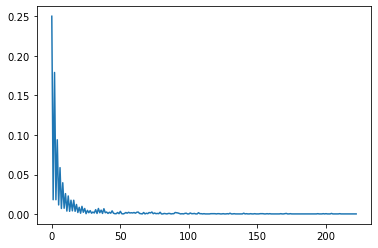

In [58]:
plt.plot(histogram)

### This follows a power law distribution

In [59]:
df = pd.DataFrame(index=G_sc.nodes())
df['clustering'] = pd.Series(nx.clustering(G_sc))
df['in_degree'] = pd.Series(dict(in_deg))

df['out_degree'] = pd.Series(dict(out_deg))
df['degree_centrality'] = pd.Series(nx.degree_centrality(G))
df['closeness'] = pd.Series(closeness)

In [60]:
df['betweeness'] = pd.Series(betweeness)
df['pr'] = pd.Series(pr)
df['hits_hubs'] = pd.Series(hits[0])
df['hits_auth'] = pd.Series(hits[1])

In [61]:
df.head()

,clustering,in_degree,out_degree,degree_centrality,closeness,betweeness,pr,hits_hubs,hits_auth
AER,0.525952,0.005368,0.005070,0.010222,0.281836,2.529012e-05,0.000347,0.000435,0.000437
KZN,0.423810,0.006263,0.006263,0.012266,0.283672,5.094607e-05,0.000409,0.000428,0.000429
ASF,0.571429,0.002088,0.002088,0.004089,0.271740,8.119928e-07,0.000163,0.000229,0.000228
MRV,0.495833,0.004772,0.004772,0.009346,0.292022,3.069963e-05,0.000315,0.000475,0.000478
CEK,0.538462,0.004175,0.004175,0.008178,0.273558,4.533672e-06,0.000277,0.000325,0.000327
